<a href="https://colab.research.google.com/github/Nailaskn/Analisis-Numerik-Gerai-Donat/blob/main/Naila_Secondaiva_Arta_Putri_25083010013_Analisis_Numerik_Gerai_Donat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Numerik Hubungan Volume Penjualan terhadap Revenue dan Penentuan Break Even Point pada Gerai Donat

Analisis ini dilakukan untuk mengetahui hubungan antara jumlah penjualan dengan revenue pada lima gerai donat yang memiliki strategi pemasaran berbeda. Analisis meliputi visualisasi hubungan jumlah penjualan dengan revenue, penerapan regresi untuk mengetahui bentuk tren revenue terhadap volume penjualan, serta penentuan Break Even Point (BEP) menggunakan metode numerik.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

Library yang digunakan dalam analisis ini adalah Pandas untuk mengolah data, NumPy untuk perhitungan numerik, Matplotlib untuk membuat visualisasi, serta LinearRegression dari Scikit-learn untuk membangun model regresi linear.

In [4]:
df = pd.read_csv("sintesis_data_donat_harian.csv")

Dataset yang digunakan merupakan data penjualan harian dari lima gerai donat, yaitu Gerai A, Gerai B, Gerai C, Gerai D, dan Gerai E. Data terdiri dari informasi mengenai tanggal, gerai, harga jual, jumlah produk terjual, pendapatan kotor, biaya variabel, fixed cost harian, dan balance.

Dataset ini digunakan untuk menganalisis hubungan antara volume penjualan dengan revenue serta menentukan jumlah penjualan yang diperlukan untuk mencapai kondisi Break Even Point (BEP).

In [5]:
df.head()

,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Tanggal                 450 non-null    object
 1   Gerai                   450 non-null    object
 2   Harga Jual (Rp)         450 non-null    int64 
 3   Jumlah Terjual (Unit)   450 non-null    int64 
 4   Pendapatan Kotor (Rp)   450 non-null    int64 
 5   Biaya Variabel (Rp)     450 non-null    int64 
 6   Fixed Cost Harian (Rp)  450 non-null    int64 
 7   Balance (Rp)            450 non-null    int64 
dtypes: int64(6), object(2)
memory usage: 28.3+ KB


In [7]:
df.groupby("Gerai").agg({
    "Jumlah Terjual (Unit)": ["min", "max", "mean"],
    "Pendapatan Kotor (Rp)": ["min", "max", "mean"],
    "Biaya Variabel (Rp)": ["min", "max", "mean"],
    "Fixed Cost Harian (Rp)": "mean"
})

Jumlah Terjual (Unit)                  Pendapatan Kotor (Rp)           \
                          min  max        mean                   min      max   
Gerai                                                                           
Gerai A                    81  131   99.100000               2025000  3275000   
Gerai B                   435  710  527.500000               3480000  5680000   
Gerai C                   220  522  328.933333               2420000  5742000   
Gerai D                   103  223  149.833333               2060000  4460000   
Gerai E                   153  332  226.644444               2295000  4980000   

                      Biaya Variabel (Rp)                         \
                 mean                 min      max          mean   
Gerai                                                              
Gerai A  2.477500e+06              688500  1113500  8.423500e+05   
Gerai B  4.220000e+06             1809600  2953600  2.194400e+06   
Gerai C  3.618267e+06             1064800  2526480  1.592037e+06   
Gerai D  2.996667e+06              741600  1605600  1.078800e+06   
Gerai E  3.399667e+06              963900  2091600  1.427860e+06   

        Fixed Cost Harian (Rp)  
                          mean  
Gerai                           
Gerai A              1683333.0  
Gerai B               733333.0  
Gerai C              1733333.0  
Gerai D              2666666.0  
Gerai E               800000.0

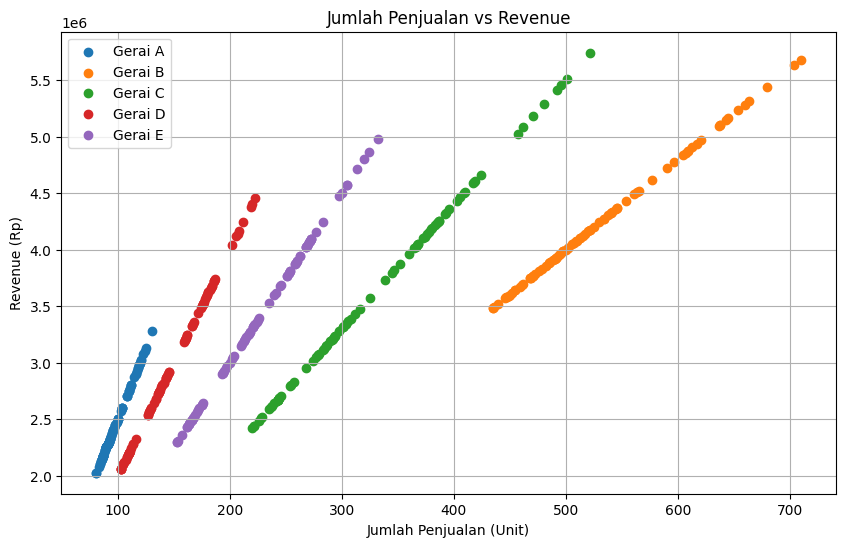

In [8]:
gerai_list = df["Gerai"].unique()

plt.figure(figsize=(10, 6))

for gerai in gerai_list:
    data = df[df["Gerai"] == gerai]

    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        data["Pendapatan Kotor (Rp)"],
        label=gerai
    )

plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue (Rp)")
plt.title("Jumlah Penjualan vs Revenue")
plt.legend()
plt.grid(True)
plt.show()

Scatter plot digunakan untuk melihat hubungan antara jumlah produk yang terjual dengan revenue pada kelima gerai. Berdasarkan grafik, terlihat adanya hubungan positif antara jumlah penjualan dengan revenue. Ketika jumlah produk yang terjual meningkat, revenue yang diperoleh juga meningkat. Titik-titik cenderung membentuk pola garis lurus.

Perbedaan posisi pola antar gerai dikarenakan setiap gerai memiliki harga jual per unit yang berbeda. Dengan volume penjualan yang sama, gerai dengan harga jual lebih tinggi akan menghasilkan revenue yang lebih besar.

Pola yang terlihat pada grafik menunjukkan bahwa hubungan antara jumlah penjualan dan revenue dapat dimodelkan menggunakan regresi linear.

# Regresi Linear Revenue
Untuk mengetahui bentuk tren revenue berdasarkan jumlah penjualan, digunakan regresi linear

Model regresi linear secara umum dinyatakan:

$
y = ax + b
$

dengan $x$ sebagai jumlah penjualan, $y$ sebagai revenue, $a$ sebagai koefisien regresi atau slope, dan $b$ sebagai intercept.

Model ini digunakan untuk mengetahui seberapa besar perubahan revenue ketika terjadi perubahan pada jumlah produk yang terjual.

In [9]:
hasil_regresi = []

for gerai in df["Gerai"].unique():

    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    model = LinearRegression()
    model.fit(X, y)

    a = model.coef_[0]
    b = model.intercept_
    r2 = model.score(X, y)

    hasil_regresi.append({
        "Gerai": gerai,
        "Slope": a,
        "Intercept": b,
        "R2": r2
    })

hasil_regresi_df = pd.DataFrame(hasil_regresi)

hasil_regresi_df

,Gerai,Slope,Intercept,R2
0,Gerai A,25000.0,-4.656613e-10,1.0
1,Gerai B,8000.0,0.000000e+00,1.0
2,Gerai C,11000.0,4.656613e-10,1.0
3,Gerai D,20000.0,-9.313226e-10,1.0
4,Gerai E,15000.0,-4.656613e-10,1.0


In [10]:
for _, row in hasil_regresi_df.iterrows():
    print(
        f"{row['Gerai']}: "
        f"Revenue = {row['Slope']:.2f}x + {row['Intercept']:.2f}"
    )

Gerai A: Revenue = 25000.00x + -0.00
Gerai B: Revenue = 8000.00x + 0.00
Gerai C: Revenue = 11000.00x + 0.00
Gerai D: Revenue = 20000.00x + -0.00
Gerai E: Revenue = 15000.00x + -0.00


Berdasarkan hasil regresi, hubungan antara jumlah penjualan dengan revenue pada kelima gerai membentuk model linear. Persamaan regresi menunjukkan revenue berbanding lurus dengan jumlah produk yang terjual.

Nilai slope menunjukkan perubahan revenue untuk setiap tambahan satu unit produk yang terjual.

In [11]:
hasil_regresi_df[["Gerai", "Slope", "Intercept", "R2"]]

,Gerai,Slope,Intercept,R2
0,Gerai A,25000.0,-4.656613e-10,1.0
1,Gerai B,8000.0,0.000000e+00,1.0
2,Gerai C,11000.0,4.656613e-10,1.0
3,Gerai D,20000.0,-9.313226e-10,1.0
4,Gerai E,15000.0,-4.656613e-10,1.0


Berdasarkan hasil regresi, nilai $R^2$ pada kelima gerai mendekati 1. Hal ini menunjukkan bahwa model regresi linear dapat menjelaskan hubungan antara jumlah penjualan dan revenue dengan sangat baik.

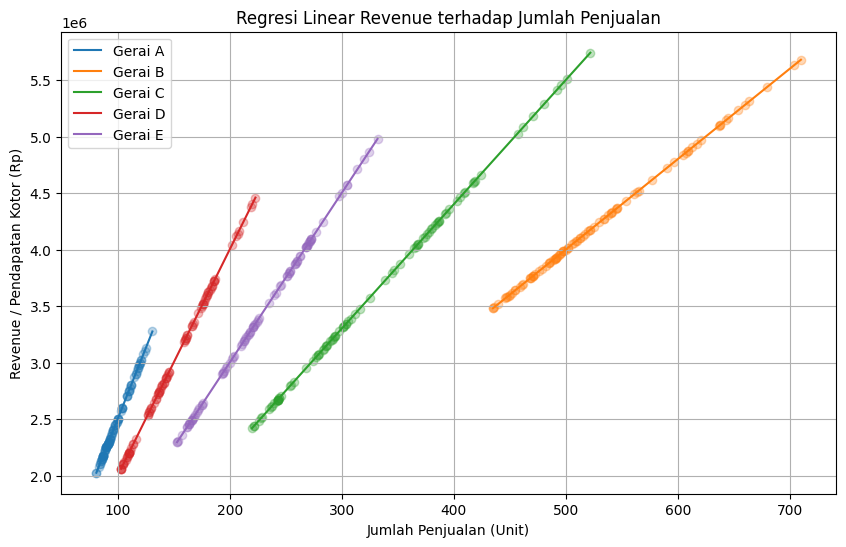

In [21]:
plt.figure(figsize=(10, 6))

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    X = data[["Jumlah Terjual (Unit)"]]
    y = data["Pendapatan Kotor (Rp)"]

    # Membuat model regresi
    model = LinearRegression()
    model.fit(X, y)

    # Membuat nilai X untuk garis regresi
    x_line = np.linspace(
        data["Jumlah Terjual (Unit)"].min(),
        data["Jumlah Terjual (Unit)"].max(),
        100
    )

    # Mengubah x_line menjadi DataFrame dengan nama kolom yang sama
    x_line_df = pd.DataFrame(
        x_line,
        columns=["Jumlah Terjual (Unit)"]
    )

    # Prediksi revenue
    y_line = model.predict(x_line_df)

    # Scatter plot data asli
    plt.scatter(
        data["Jumlah Terjual (Unit)"],
        y,
        alpha=0.3
    )

    # Garis regresi
    plt.plot(
        x_line,
        y_line,
        label=gerai
    )

plt.xlabel("Jumlah Penjualan (Unit)")
plt.ylabel("Revenue / Pendapatan Kotor (Rp)")
plt.title("Regresi Linear Revenue terhadap Jumlah Penjualan")
plt.legend()
plt.grid(True)
plt.show()

Garis yang terbentuk pada grafik regresi memiliki arah positif, sehingga peningkatan jumlah penjualan diikuti oleh peningkatan revenue. Hal ini mendukung hasil perhitungan regresi sebelumnya yang menyatakan hubungan antara jumlah penjualan dan revenue pada kelima gerai dapat direpresentasikan menggunakan model linear.

In [14]:
biaya_gerai = []

for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    harga = data["Harga Jual (Rp)"].iloc[0]
    fixed_cost = data["Fixed Cost Harian (Rp)"].iloc[0]

    total_variable_cost = data["Biaya Variabel (Rp)"].sum()
    total_units = data["Jumlah Terjual (Unit)"].sum()

    variable_cost_per_unit = total_variable_cost / total_units

    biaya_gerai.append({
        "Gerai": gerai,
        "Harga Jual": harga,
        "Biaya Variabel per Unit": variable_cost_per_unit,
        "Fixed Cost": fixed_cost
    })

biaya_df = pd.DataFrame(biaya_gerai)

biaya_df

,Gerai,Harga Jual,Biaya Variabel per Unit,Fixed Cost
0,Gerai A,25000,8500.0,1683333
1,Gerai B,8000,4160.0,733333
2,Gerai C,11000,4840.0,1733333
3,Gerai D,20000,7200.0,2666666
4,Gerai E,15000,6300.0,800000


Biaya variabel per unit diperoleh dengan membagi total biaya variabel dengan total jumlah produk yang terjual. Nilai tersebut digunakan untuk membentuk fungsi total cost masing-masing gerai.

Selain biaya variabel per unit, fixed cost harian juga digunakan karena biaya tersebut tetap harus ditanggung oleh gerai meskipun jumlah produk yang terjual berubah.

In [15]:
fungsi_bep = {}

for _, row in biaya_df.iterrows():
    gerai = row["Gerai"]
    harga = row["Harga Jual"]
    vc_unit = row["Biaya Variabel per Unit"]
    fixed = row["Fixed Cost"]

    fungsi_bep[gerai] = lambda x, h=harga, vc=vc_unit, fc=fixed: (
        h * x - (vc * x + fc)
    )

#Fungsi BEP

Fungsi BEP dibentuk dari selisih antara revenue dan total cost:

$
f(x) = Revenue(x) - TC(x)
$

Jika $f(x) < 0$, revenue masih lebih kecil daripada total cost sehingga kondisi gerai masih di bawah titik impas.

Jika $f(x) = 0$, revenue sama dengan total cost sehingga gerai berada pada kondisi Break Even Point.

Jika $f(x) > 0$, revenue lebih besar daripada total cost sehingga terdapat selisih positif antara pendapatan dan biaya.

BEP dapat dicari dengan menemukan akar dari fungsi $f(x)=0$.

In [16]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError("Interval tidak mengandung akar.")

    hasil_iterasi = []

    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        fc = f(c)

        hasil_iterasi.append({
            "Iterasi": i,
            "a": a,
            "b": b,
            "c": c,
            "f(c)": fc
        })

        if abs(fc) < tol or abs(b - a) < tol:
            break

        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    return c, pd.DataFrame(hasil_iterasi)

Metode Bisection merupakan metode numerik yang digunakan untuk mencari akar suatu fungsi. Metode ini membagi interval pencarian menjadi dua bagian secara berulang.

Metode Bisection digunakan untuk mencari jumlah penjualan $x$ yang menghasilkan:

$
f(x) = 0
$

Interval awal dipilih dari kondisi fungsi pada batas bawah dan batas atas. Jika nilai fungsi pada kedua batas memiliki tanda yang berbeda, maka terdapat akar di dalam interval.

Proses pembagian interval dilakukan secara berulang hingga nilai fungsi mendekati nol atau ukuran interval telah mencapai nilai toleransi yang ditentukan.

In [17]:
for gerai, f in fungsi_bep.items():
    print(gerai)
    print("f(0)   =", f(0))
    print("f(500) =", f(500))
    print()

Gerai A
f(0)   = -1683333.0
f(500) = 6566667.0

Gerai B
f(0)   = -733333.0
f(500) = 1186667.0

Gerai C
f(0)   = -1733333.0
f(500) = 1346667.0

Gerai D
f(0)   = -2666666.0
f(500) = 3733334.0

Gerai E
f(0)   = -800000.0
f(500) = 3550000.0




Interval diatas kemudian digunakan sebagai interval awal dalam proses pencarian akar menggunakan metode Bisection.

In [18]:
hasil_bep = []

for gerai, f in fungsi_bep.items():
    akar, iterasi = bisection(f, 0, 500)

    hasil_bep.append({
        "Gerai": gerai,
        "BEP (Unit)": akar,
        "BEP Dibulatkan": np.ceil(akar)
    })

hasil_bep_df = pd.DataFrame(hasil_bep)

hasil_bep_df

,Gerai,BEP (Unit),BEP Dibulatkan
0,Gerai A,102.020182,103.0
1,Gerai B,190.972136,191.0
2,Gerai C,281.385228,282.0
3,Gerai D,208.333281,209.0
4,Gerai E,91.954023,92.0


Nilai BEP numerik dapat berupa bilangan desimal karena diperoleh dari proses perhitungan matematis. Karena jumlah produk yang terjual harus berupa bilangan bulat, hasil tersebut dibulatkan ke atas untuk menentukan jumlah unit penjualan yang harus dicapai.

In [19]:
for _, row in biaya_df.iterrows():
    gerai = row["Gerai"]
    harga = row["Harga Jual"]
    vc = row["Biaya Variabel per Unit"]
    fc = row["Fixed Cost"]

    print(
        f"{gerai}: f(x) = "
        f"{harga:.2f}x - ({vc:.2f}x + {fc:.2f})"
    )

Gerai A: f(x) = 25000.00x - (8500.00x + 1683333.00)
Gerai B: f(x) = 8000.00x - (4160.00x + 733333.00)
Gerai C: f(x) = 11000.00x - (4840.00x + 1733333.00)
Gerai D: f(x) = 20000.00x - (7200.00x + 2666666.00)
Gerai E: f(x) = 15000.00x - (6300.00x + 800000.00)


Akar dari masing-masing fungsi tersebut menunjukkan jumlah penjualan ketika revenue sama dengan total cost.

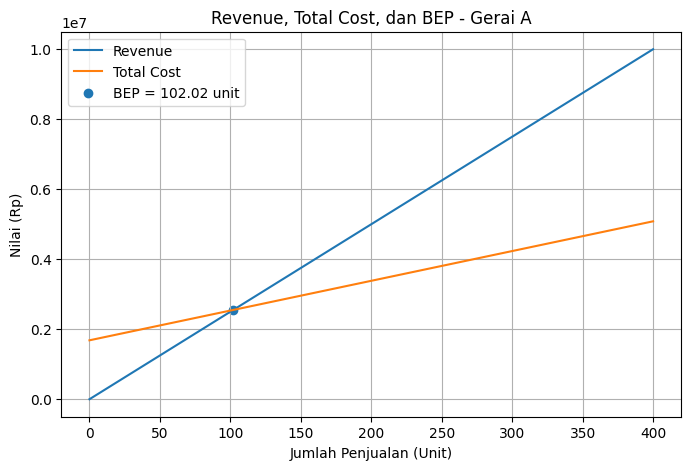

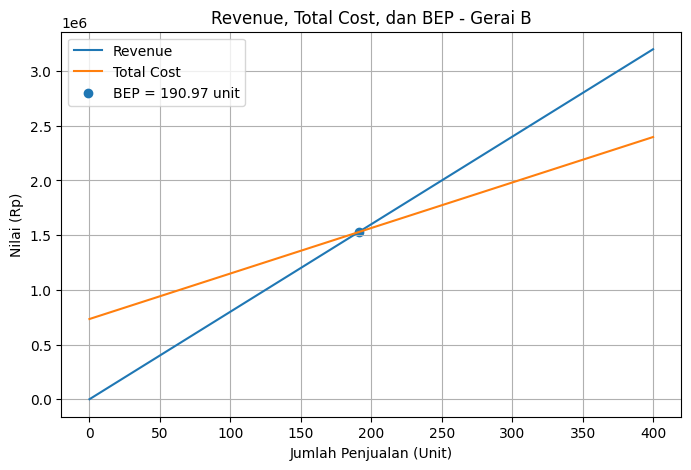

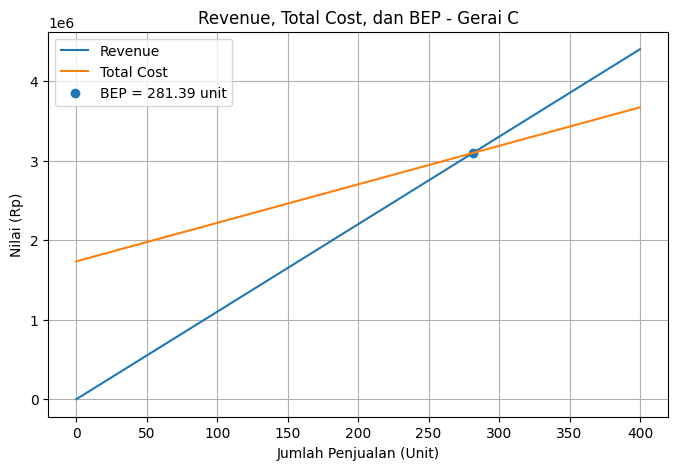

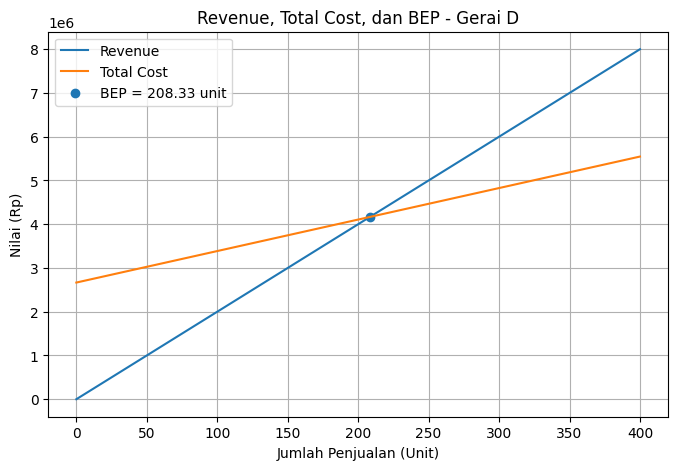

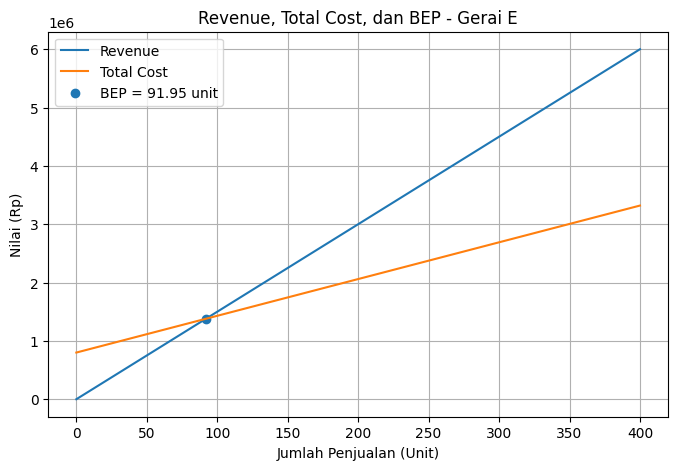

In [20]:
for gerai in df["Gerai"].unique():
    data = df[df["Gerai"] == gerai]

    harga = data["Harga Jual (Rp)"].iloc[0]
    fixed = data["Fixed Cost Harian (Rp)"].iloc[0]

    vc_per_unit = (
        data["Biaya Variabel (Rp)"].sum()
        / data["Jumlah Terjual (Unit)"].sum()
    )

    x = np.linspace(0, 400, 100)

    revenue = harga * x
    total_cost = vc_per_unit * x + fixed

    bep = hasil_bep_df[
        hasil_bep_df["Gerai"] == gerai
    ]["BEP (Unit)"].iloc[0]

    plt.figure(figsize=(8, 5))

    plt.plot(x, revenue, label="Revenue")
    plt.plot(x, total_cost, label="Total Cost")
    plt.scatter(
        bep,
        harga * bep,
        label=f"BEP = {bep:.2f} unit"
    )

    plt.xlabel("Jumlah Penjualan (Unit)")
    plt.ylabel("Nilai (Rp)")
    plt.title(f"Revenue, Total Cost, dan BEP - {gerai}")
    plt.legend()
    plt.grid(True)
    plt.show()

#Visualisasi Revenue, Total Cost, dan BEP

Grafik digunakan untuk menampilkan hubungan antara revenue dan total cost terhadap jumlah penjualan. Titik perpotongan antara kedua garis menunjukkan kondisi ketika revenue sama dengan total cost.

Pada jumlah penjualan sebelum titik BEP, garis total cost berada di atas revenue sehingga pendapatan belum mampu menutupi seluruh biaya. Ketika jumlah penjualan mencapai titik BEP, kedua nilai tersebut menjadi sama.

Setelah melewati titik BEP, revenue berada di atas total cost sehingga selisih antara revenue dan biaya menjadi positif. Grafik ini memperlihatkan hasil pencarian akar yang telah diperoleh menggunakan metode Bisection.

#Kesimpulan

Dari hasil analisis, jumlah penjualan dan revenue pada kelima gerai memiliki hubungan positif dan linear. Hasil regresi menunjukkan bahwa peningkatan jumlah produk yang terjual akan meningkatkan revenue, dengan nilai $(R^2)$ yang mendekati 1 pada setiap gerai.

BEP dicari dengan membentuk fungsi revenue dikurangi total cost dan mencari nilai akarnya menggunakan metode Bisection. Hasilnya, Gerai A membutuhkan 103 unit, Gerai B 191 unit, Gerai C 282 unit, Gerai D 209 unit, dan Gerai E 92 unit untuk mencapai BEP setelah pembulatan ke atas.

Perbedaan BEP dipengaruhi oleh harga jual, biaya variabel, dan fixed cost masing-masing gerai. Dengan demikian, regresi linear dapat digunakan untuk melihat tren revenue, sedangkan metode Bisection dapat digunakan untuk menentukan jumlah penjualan pada titik impas.